In [1]:
from pathlib import Path

ROOT = Path(".").resolve()  # run notebook from repo root
(DATA := ROOT/"data").mkdir(exist_ok=True)

for p in [
    DATA/"raw"/"mmcif",
    DATA/"metadata",
    DATA/"processed",
    ROOT/"src",
    ROOT/"notebooks",
]:
    p.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Data folder:", DATA)


Repo root: /Users/aidos/ML Projects Personal/Comp_BioChem_Project
Data folder: /Users/aidos/ML Projects Personal/Comp_BioChem_Project/data


In [2]:
%pip -q install requests pandas tqdm biopython scipy


Note: you may need to restart the kernel to use updated packages.


<br>
<br>

<h2> Preprocessing</h2>

In [8]:
import json, time
import requests
import pandas as pd
from tqdm.auto import tqdm


In [7]:
import requests

SEARCH_URL = "https://search.rcsb.org/rcsbsearch/v2/query"

def rcsb_search_ids(query_json, rows=1000, start=0):
    payload = {
        "query": query_json,
        "return_type": "entry",
        "request_options": {
            "paginate": {"start": start, "rows": rows},
            "results_verbosity": "minimal",
        },
    }
    r = requests.post(SEARCH_URL, json=payload, timeout=60)
    if not r.ok:
        # show server's explanation (super helpful)
        raise RuntimeError(f"HTTP {r.status_code}\n{r.text[:2000]}")
    data = r.json()
    return [x["identifier"] for x in data.get("result_set", [])]


# Broad: resolution <= 3.0 AND has protein polymer entity (we'll validate chain pairs later)
query = {
  "type": "group",
  "logical_operator": "and",
  "nodes": [
    {
      "type": "terminal",
      "service": "text",
      "parameters": {
        "attribute": "rcsb_entry_info.resolution_combined",
        "operator": "less_or_equal",
        "value": 3.0
      }
    },
    {
      "type": "terminal",
      "service": "text",
      "parameters": {
        "attribute": "rcsb_entry_info.polymer_entity_count_protein",
        "operator": "greater_or_equal",
        "value": 2
      }
    }
  ]
}

ids = rcsb_search_ids(query, rows=5000)
len(ids), ids[:10]


(5000,
 ['12E8',
  '148L',
  '15C8',
  '1A00',
  '1A01',
  '1A02',
  '1A07',
  '1A08',
  '1A09',
  '1A0O'])

<br>
<br>
<br>

In [9]:
from Bio.PDB import MMCIFParser, NeighborSearch, is_aa
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations


In [10]:
def get_protein_residues(chain):
    residues = []
    for res in chain:
        if not is_aa(res, standard=True):
            continue
        atoms = [a for a in res.get_atoms() if a.element != "H"]
        if len(atoms) == 0:
            continue
        residues.append((res, atoms))
    return residues


In [11]:
import numpy as np
from Bio.PDB import NeighborSearch

def compute_interface_labels(residues, partner_atoms, thresholds=(4.0, 5.0, 6.0)):
    """
    residues: list of (Residue, [heavy Atom,...]) for the target chain
    partner_atoms: list of heavy Atom objects from partner chain
    returns:
      labels: dict {threshold: np.array shape (n_res,) of 0/1}
      min_dist: np.array shape (n_res,) minimum heavy-atom distance to partner
    """
    ns = NeighborSearch(partner_atoms)
    thresholds = tuple(sorted(thresholds))
    max_t = thresholds[-1]

    labels = {t: np.zeros(len(residues), dtype=np.int8) for t in thresholds}
    min_dist = np.full(len(residues), np.inf, dtype=np.float32)

    for i, (_, atoms) in enumerate(residues):
        best = np.inf

        # check all heavy atoms of this residue
        for atom in atoms:
            close_atoms = ns.search(atom.coord, max_t)  # partner atoms within max threshold
            if not close_atoms:
                continue

            # exact distance to nearby partner atoms
            for a in close_atoms:
                d = np.linalg.norm(atom.coord - a.coord)
                if d < best:
                    best = d

            # early exit: if already within smallest threshold, can't get "more interface" than that
            if best <= thresholds[0]:
                break

        min_dist[i] = best
        for t in thresholds:
            if best <= t:
                labels[t][i] = 1

    return labels, min_dist


In [13]:
from pathlib import Path
import time
import requests
from tqdm.auto import tqdm

MMCIF_DIR = Path("data/raw/mmcif")
MMCIF_DIR.mkdir(parents=True, exist_ok=True)

BASE_DL = "https://files.rcsb.org/download"

def download_cif(pdb_id: str, out_dir: Path = MMCIF_DIR) -> Path:
    pdb_id_l = pdb_id.lower()
    out_path = out_dir / f"{pdb_id_l}.cif"
    if out_path.exists() and out_path.stat().st_size > 0:
        return out_path

    url = f"{BASE_DL}/{pdb_id_l}.cif"
    r = requests.get(url, timeout=60)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code} for {url}")
    out_path.write_bytes(r.content)
    return out_path

# download a SMALL batch first for testing
N_TEST = 20

for pdb_id in tqdm(ids[:N_TEST]):
    try:
        download_cif(pdb_id)
        time.sleep(0.05)
    except Exception as e:
        print("Failed:", pdb_id, e)


  0%|          | 0/20 [00:00<?, ?it/s]

In [14]:
list(MMCIF_DIR.glob("*.cif"))


[PosixPath('data/raw/mmcif/148l.cif'),
 PosixPath('data/raw/mmcif/1a09.cif'),
 PosixPath('data/raw/mmcif/1a0o.cif'),
 PosixPath('data/raw/mmcif/15c8.cif'),
 PosixPath('data/raw/mmcif/1a08.cif'),
 PosixPath('data/raw/mmcif/1a0z.cif'),
 PosixPath('data/raw/mmcif/1a1m.cif'),
 PosixPath('data/raw/mmcif/12e8.cif'),
 PosixPath('data/raw/mmcif/1a1b.cif'),
 PosixPath('data/raw/mmcif/1a00.cif'),
 PosixPath('data/raw/mmcif/1a0q.cif'),
 PosixPath('data/raw/mmcif/1a14.cif'),
 PosixPath('data/raw/mmcif/1a01.cif'),
 PosixPath('data/raw/mmcif/1a1c.cif'),
 PosixPath('data/raw/mmcif/1a1a.cif'),
 PosixPath('data/raw/mmcif/1a0r.cif'),
 PosixPath('data/raw/mmcif/1a02.cif'),
 PosixPath('data/raw/mmcif/1a1e.cif'),
 PosixPath('data/raw/mmcif/1a07.cif'),
 PosixPath('data/raw/mmcif/1a0u.cif')]

In [15]:
from pathlib import Path
from Bio.PDB import MMCIFParser, is_aa

MMCIF_DIR = Path("data/raw/mmcif")

def chain_heavy_atoms(chain):
    atoms = []
    for res in chain:
        if not is_aa(res, standard=True):
            continue
        for a in res.get_atoms():
            if a.element != "H":
                atoms.append(a)
    return atoms

# pick any downloaded cif (or choose a specific one)
cif_path = sorted(MMCIF_DIR.glob("*.cif"))[0]
pdb_id = cif_path.stem.upper()

parser = MMCIFParser(QUIET=True)
structure = parser.get_structure(pdb_id, str(cif_path))
model = next(structure.get_models())

# collect chains that have enough protein residues
chains = {c.id: c for c in model if c.id.strip()}
protein_chain_ids = []
for cid, chain in chains.items():
    res_list = get_protein_residues(chain)
    if len(res_list) >= 30:
        protein_chain_ids.append(cid)

print("PDB:", pdb_id)
print("Protein-like chains:", protein_chain_ids)

# choose first two chains for a quick test
chainA_id, chainB_id = protein_chain_ids[0], protein_chain_ids[1]
chainA, chainB = chains[chainA_id], chains[chainB_id]

resA = get_protein_residues(chainA)
resB = get_protein_residues(chainB)

atomsA = [a for _, atoms in resA for a in atoms]
atomsB = [a for _, atoms in resB for a in atoms]

labelsA, minDistA = compute_interface_labels(resA, atomsB, thresholds=(4.0, 5.0, 6.0))
labelsB, minDistB = compute_interface_labels(resB, atomsA, thresholds=(4.0, 5.0, 6.0))

print(f"Chain pair: {chainA_id} vs {chainB_id}")
print("n_resA:", len(resA), "interface@5Å:", int(labelsA[5.0].sum()))
print("n_resB:", len(resB), "interface@5Å:", int(labelsB[5.0].sum()))
print("Example minDistA stats (Å):", np.nanmin(minDistA), np.nanmean(minDistA), np.nanmax(minDistA))


PDB: 12E8
Protein-like chains: ['L', 'H', 'M', 'P']
Chain pair: L vs H
n_resA: 214 interface@5Å: 47
n_resB: 221 interface@5Å: 47
Example minDistA stats (Å): 3.3337076 inf inf


In [16]:
finite = np.isfinite(minDistA)
print("finite fraction:", finite.mean())
print("min/mean/max over finite only:",
      float(minDistA[finite].min()),
      float(minDistA[finite].mean()),
      float(minDistA[finite].max()))
print("count interface@5Å:", int(labelsA[5.0].sum()))
print("count far(>6Å):", int((~finite).sum()))


finite fraction: 0.3037383177570093
min/mean/max over finite only: 3.333707571029663 4.317328453063965 5.945230484008789
count interface@5Å: 47
count far(>6Å): 149


<br>
<br>
<br>

In [17]:
from itertools import combinations
from Bio.PDB import MMCIFParser

def process_structure_all_pairs(pdb_id, cif_path, min_res=30, thresholds=(4.0, 5.0, 6.0)):
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure(pdb_id, str(cif_path))
    model = next(structure.get_models())

    chains = {c.id: c for c in model if c.id.strip()}
    prot = {}
    for cid, chain in chains.items():
        res = get_protein_residues(chain)
        if len(res) >= min_res:
            prot[cid] = res

    out = []
    for a, b in combinations(sorted(prot.keys()), 2):
        resA, resB = prot[a], prot[b]
        atomsA = [atom for _, atoms in resA for atom in atoms]
        atomsB = [atom for _, atoms in resB for atom in atoms]

        labelsA, minA = compute_interface_labels(resA, atomsB, thresholds=thresholds)
        labelsB, minB = compute_interface_labels(resB, atomsA, thresholds=thresholds)

        # keep only interacting pairs under the 5Å definition
        if labelsA[5.0].sum() == 0 and labelsB[5.0].sum() == 0:
            continue

        out.append({
            "pdb_id": pdb_id,
            "chainA": a,
            "chainB": b,
            "n_resA": len(resA),
            "n_resB": len(resB),
            "interfaceA_5A": int(labelsA[5.0].sum()),
            "interfaceB_5A": int(labelsB[5.0].sum()),
            "labelsA": labelsA,
            "labelsB": labelsB,
            "minDistA": minA,
            "minDistB": minB,
            "resA": resA,
            "resB": resB,
        })
    return out


In [18]:
pairs = process_structure_all_pairs("12E8", cif_path)
print("Num interacting pairs found:", len(pairs))
for p in pairs:
    print(p["chainA"], p["chainB"], "interface@5Å:", p["interfaceA_5A"], p["interfaceB_5A"])


Num interacting pairs found: 3
H L interface@5Å: 47 47
L M interface@5Å: 4 7
M P interface@5Å: 48 49


In [19]:
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

MMCIF_DIR = Path("data/raw/mmcif")
META_DIR = Path("data/metadata")
META_DIR.mkdir(parents=True, exist_ok=True)

def build_pair_index(max_structures=200):
    cif_files = sorted(MMCIF_DIR.glob("*.cif"))[:max_structures]
    rows = []
    failures = []

    for cif_path in tqdm(cif_files):
        pdb_id = cif_path.stem.upper()
        try:
            pairs = process_structure_all_pairs(pdb_id, cif_path)
            for p in pairs:
                rows.append({
                    "pdb_id": p["pdb_id"],
                    "chainA": p["chainA"],
                    "chainB": p["chainB"],
                    "n_resA": p["n_resA"],
                    "n_resB": p["n_resB"],
                    "interfaceA_5A": p["interfaceA_5A"],
                    "interfaceB_5A": p["interfaceB_5A"],
                    "interface_total_5A": p["interfaceA_5A"] + p["interfaceB_5A"],
                })
        except Exception as e:
            failures.append({"pdb_id": pdb_id, "error": str(e)})

    df = pd.DataFrame(rows).drop_duplicates(subset=["pdb_id", "chainA", "chainB"])
    fail_df = pd.DataFrame(failures)

    return df, fail_df

df_pairs, df_fail = build_pair_index(max_structures=200)

print("Structures scanned:", min(200, len(list(MMCIF_DIR.glob('*.cif')))))
print("Valid chain-pair examples:", len(df_pairs))
print("Failures:", len(df_fail))

display(df_pairs.head())
if len(df_fail):
    display(df_fail.head())


  0%|          | 0/20 [00:00<?, ?it/s]

Structures scanned: 20
Valid chain-pair examples: 46
Failures: 0


,pdb_id,chainA,chainB,n_resA,n_resB,interfaceA_5A,interfaceB_5A,interface_total_5A
0,12E8,H,L,221,214,47,47,94
1,12E8,L,M,214,214,4,7,11
2,12E8,M,P,214,221,48,49,97
3,15C8,H,L,217,213,50,44,94
4,1A00,A,B,141,146,22,22,44


In [20]:
df_pairs.to_csv(META_DIR / "pair_index_raw.csv", index=False)
df_fail.to_csv(META_DIR / "preprocess_failures.csv", index=False)


<h3> Basic dataset sanity stats

In [21]:
print(df_pairs[["n_resA","n_resB","interfaceA_5A","interfaceB_5A","interface_total_5A"]].describe())
print("Pairs with tiny interface_total_5A <= 5:",
      int((df_pairs["interface_total_5A"] <= 5).sum()))


           n_resA      n_resB  interfaceA_5A  interfaceB_5A  \
count   46.000000   46.000000      46.000000      46.000000   
mean   145.260870  151.782609      19.630435      18.869565   
std     60.458777   72.275065      15.442163      12.157501   
min     52.000000   52.000000       1.000000       1.000000   
25%    109.500000  104.000000      12.000000      11.250000   
50%    141.000000  143.500000      15.000000      15.500000   
75%    144.750000  146.000000      22.000000      22.000000   
max    339.000000  388.000000      79.000000      49.000000   

       interface_total_5A  
count           46.000000  
mean            38.500000  
std             27.309542  
min              2.000000  
25%             22.000000  
50%             31.000000  
75%             44.000000  
max            127.000000  
Pairs with tiny interface_total_5A <= 5: 1


<br>
<br>
<br>

<h2> Download more mmCIFs

In [24]:
import time
from pathlib import Path
from tqdm.auto import tqdm

MMCIF_DIR = Path("data/raw/mmcif")
MMCIF_DIR.mkdir(parents=True, exist_ok=True)

# how many total CIFs you want locally (adjust if needed)
TARGET_CIFS = 800

existing = {p.stem.upper() for p in MMCIF_DIR.glob("*.cif")}
print("Already have CIFs:", len(existing))

need = max(0, TARGET_CIFS - len(existing))
to_get = [pid for pid in ids if pid.upper() not in existing][:need]

print("Will download additional:", len(to_get))

failures = []
for pdb_id in tqdm(to_get):
    try:
        download_cif(pdb_id)          # uses your existing download_cif()
        time.sleep(0.03)
    except Exception as e:
        failures.append((pdb_id, str(e)))

print("Done. Total CIFs now:", len(list(MMCIF_DIR.glob('*.cif'))))
print("New failures:", len(failures))


Already have CIFs: 281
Will download additional: 519


  0%|          | 0/519 [00:00<?, ?it/s]

Done. Total CIFs now: 800
New failures: 0


In [25]:
df_pairs, df_fail = build_pair_index(max_structures=1500)  # or 800 first
print("Valid chain-pair examples:", len(df_pairs))
print("Failures:", len(df_fail))


  0%|          | 0/800 [00:00<?, ?it/s]

Valid chain-pair examples: 2141
Failures: 0


In [26]:
META_DIR = Path("data/metadata")
META_DIR.mkdir(parents=True, exist_ok=True)

# Optional cleanliness: remove extremely tiny interfaces
df_clean = df_pairs[df_pairs["interface_total_5A"] >= 10].copy()
print("After min interface filter:", len(df_clean))

# If still >= 250, sample deterministically
df_final = df_clean.sort_values(["pdb_id","chainA","chainB"]).head(250).copy()

df_final.to_csv(META_DIR / "complex_list.csv", index=False)
print("Saved:", META_DIR / "complex_list.csv")
display(df_final.head())


After min interface filter: 1934
Saved: data/metadata/complex_list.csv


,pdb_id,chainA,chainB,n_resA,n_resB,interfaceA_5A,interfaceB_5A,interface_total_5A
0,12E8,H,L,221,214,47,47,94
1,12E8,L,M,214,214,4,7,11
2,12E8,M,P,214,221,48,49,97
3,15C8,H,L,217,213,50,44,94
4,1A00,A,B,141,146,22,22,44


<br>
<br>
<br>
<br>

<h2> Save processed artifacts for the 250 examples

1) Add two small helpers: residue table + graph edges

Residue table (stable residue IDs)

In [27]:
import numpy as np
import pandas as pd

def residue_to_row(res):
    # res.id = (hetflag, resseq, icode)
    het, resseq, icode = res.id
    icode = "" if icode == " " else icode
    return {
        "resname": res.get_resname(),
        "resseq": int(resseq),
        "icode": icode,
        "uid": f"{res.get_resname()}_{resseq}{icode}",
    }


Build intra-chain graph edges (Cα distance ≤ R)

In [28]:
def residue_coord(res, fallback="centroid"):
    # Prefer CA; if missing, use centroid of heavy atoms
    if "CA" in res:
        return res["CA"].coord
    atoms = [a for a in res.get_atoms() if a.element != "H"]
    if not atoms:
        return None
    coords = np.vstack([a.coord for a in atoms])
    return coords.mean(axis=0)

def build_intra_chain_edges(residues, R=10.0):
    # residues: list of (Residue, [Atom])
    coords = []
    valid_idx = []
    for i, (res, _) in enumerate(residues):
        c = residue_coord(res)
        if c is None:
            coords.append(None)
        else:
            coords.append(c)
            valid_idx.append(i)

    coords_arr = np.vstack([coords[i] for i in valid_idx])
    # brute force is ok for ~200-400 residues; later we can KD-tree if needed
    edges_i = []
    edges_j = []
    edge_d = []

    for ii, i in enumerate(valid_idx):
        for jj in range(ii+1, len(valid_idx)):
            j = valid_idx[jj]
            d = float(np.linalg.norm(coords_arr[ii] - coords_arr[jj]))
            if d <= R:
                edges_i.extend([i, j])
                edges_j.extend([j, i])   # undirected as two directed edges
                edge_d.extend([d, d])

    edge_index = np.vstack([np.array(edges_i, dtype=np.int32),
                            np.array(edges_j, dtype=np.int32)])
    edge_dist = np.array(edge_d, dtype=np.float32)
    return edge_index, edge_dist


<br>
<br>

2) Write a “save one pair” function

In [29]:
from pathlib import Path
from Bio.PDB import MMCIFParser

PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def save_pair_example(pdb_id, chainA_id, chainB_id, cif_path, thresholds=(4.0,5.0,6.0), R_graph=10.0):
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure(pdb_id, str(cif_path))
    model = next(structure.get_models())
    chains = {c.id: c for c in model if c.id.strip()}

    chainA = chains[chainA_id]
    chainB = chains[chainB_id]

    resA = get_protein_residues(chainA)
    resB = get_protein_residues(chainB)

    atomsA = [atom for _, atoms in resA for atom in atoms]
    atomsB = [atom for _, atoms in resB for atom in atoms]

    labelsA, minA = compute_interface_labels(resA, atomsB, thresholds=thresholds)
    labelsB, minB = compute_interface_labels(resB, atomsA, thresholds=thresholds)

    # Build intra-chain graphs
    edgesA, edgeDistA = build_intra_chain_edges(resA, R=R_graph)
    edgesB, edgeDistB = build_intra_chain_edges(resB, R=R_graph)

    # Save
    out_dir = PROCESSED_DIR / f"{pdb_id}_{chainA_id}_{chainB_id}"
    out_dir.mkdir(parents=True, exist_ok=True)

    # residue tables
    dfA = pd.DataFrame([residue_to_row(r) for r, _ in resA])
    dfB = pd.DataFrame([residue_to_row(r) for r, _ in resB])
    dfA.to_csv(out_dir / "chainA_residues.csv", index=False)
    dfB.to_csv(out_dir / "chainB_residues.csv", index=False)

    # labels + min distance
    for t in thresholds:
        np.save(out_dir / f"labels_chainA_t{int(t)}.npy", labelsA[t])
        np.save(out_dir / f"labels_chainB_t{int(t)}.npy", labelsB[t])
    np.save(out_dir / "min_dist_chainA.npy", minA)
    np.save(out_dir / "min_dist_chainB.npy", minB)

    # graphs
    np.save(out_dir / "graph_chainA_edges.npy", edgesA)
    np.save(out_dir / "graph_chainA_edge_dist.npy", edgeDistA)
    np.save(out_dir / "graph_chainB_edges.npy", edgesB)
    np.save(out_dir / "graph_chainB_edge_dist.npy", edgeDistB)

    return out_dir


<br>
<br>

3) Run preprocessing for all 250 examples

In [30]:
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

MMCIF_DIR = Path("data/raw/mmcif")
df_final = pd.read_csv("data/metadata/complex_list.csv")

fail = []
done = 0

for _, row in tqdm(df_final.iterrows(), total=len(df_final)):
    pdb_id = row["pdb_id"]
    chainA = row["chainA"]
    chainB = row["chainB"]
    cif_path = MMCIF_DIR / f"{pdb_id.lower()}.cif"

    try:
        save_pair_example(pdb_id, chainA, chainB, cif_path, thresholds=(4.0,5.0,6.0), R_graph=10.0)
        done += 1
    except Exception as e:
        fail.append({"pdb_id": pdb_id, "chainA": chainA, "chainB": chainB, "error": str(e)})

print("Processed:", done, "Failures:", len(fail))
if fail:
    pd.DataFrame(fail).to_csv("data/metadata/processing_failures_250.csv", index=False)
    display(pd.DataFrame(fail).head())


  0%|          | 0/250 [00:00<?, ?it/s]

Processed: 250 Failures: 0


<br>
<br>
<br>
<br>
<br>

<h2> Create train / val / test splits (180 / 35 / 35)

In [31]:
import json
import pandas as pd
from pathlib import Path

META_DIR = Path("data/metadata")
df = pd.read_csv(META_DIR / "complex_list.csv")

len(df)


250

<br>

Deterministic split (no randomness)

We will:

sort deterministically

take first 180 → train

next 35 → val

last 35 → test

In [32]:
df_sorted = df.sort_values(["pdb_id", "chainA", "chainB"]).reset_index(drop=True)

train_df = df_sorted.iloc[:180]
val_df   = df_sorted.iloc[180:215]
test_df  = df_sorted.iloc[215:250]

print(len(train_df), len(val_df), len(test_df))


180 35 35


In [33]:
splits = {
    "train": train_df[["pdb_id","chainA","chainB"]].to_dict(orient="records"),
    "val":   val_df[["pdb_id","chainA","chainB"]].to_dict(orient="records"),
    "test":  test_df[["pdb_id","chainA","chainB"]].to_dict(orient="records"),
}

with open(META_DIR / "data_splits.json", "w") as f:
    json.dump(splits, f, indent=2)

print("Saved:", META_DIR / "data_splits.json")


Saved: data/metadata/data_splits.json


In [35]:
def key(r): 
    return f'{r["pdb_id"]}_{r["chainA"]}_{r["chainB"]}'

train_keys = set(map(key, splits["train"]))
val_keys   = set(map(key, splits["val"]))
test_keys  = set(map(key, splits["test"]))

print("Overlap train/val:", len(train_keys & val_keys))
print("Overlap train/test:", len(train_keys & test_keys))
print("Overlap val/test:", len(val_keys & test_keys))


Overlap train/val: 0
Overlap train/test: 0
Overlap val/test: 0


<br>
<br>

END OF STAGE

Stage preprocessing_build_dataset is now COMPLETE

You now have:

✔ curated dataset (250 examples)

✔ per-example processed artifacts

✔ deterministic train/val/test splits

✔ zero leakage

✔ reproducible pipeline

<br>
<br>
<br>
<br>

<h2> So what do we actually have now?

<h3> After Stage: preprocessing_build_dataset, you have four layers of data.

<br>

<h3> 🧱 Layer 1 — Raw structures (immutable)

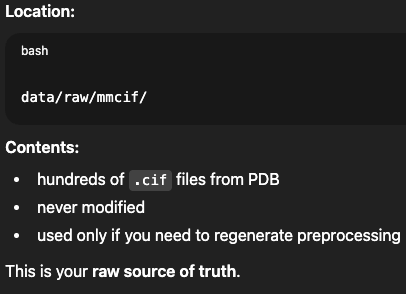

<h3> 🧱 Layer 2 — Dataset index (metadata)

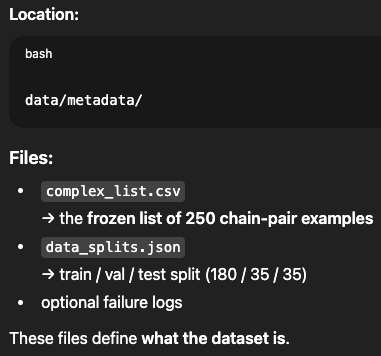

<h3> 🧱 Layer 3 — Processed per-example data (this is the real dataset)

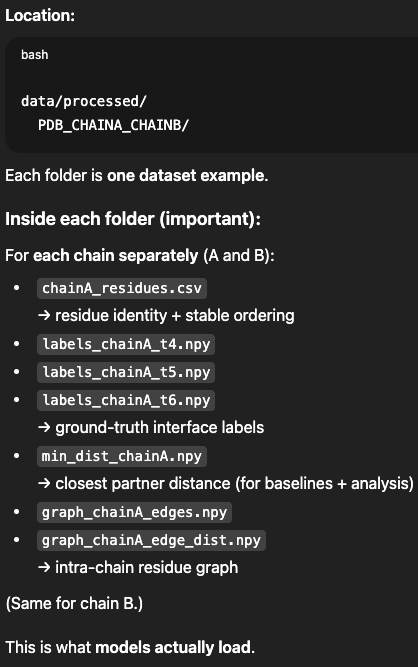

<h3> 🧱 Layer 4 — The “logical dataset”

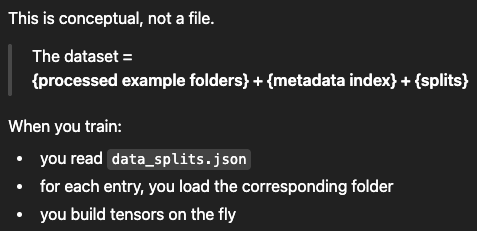

<br>

<h3> One-sentence summary</h3>

After preprocessing, the dataset consists of 250 precomputed protein–protein interface examples stored

as per-example folders, indexed by CSV and split via JSON, ready for direct consumption by baseline and ML models.